In [8]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost as xgb # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram


In [9]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/imputation/imputed_dataset.csv")  # for variogram, etc.
df = df_raw.copy()  # working copy for feature engineering + model prep
print(list(df.columns))



Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering/RF
['lon', 'lat', 'yield', 'N_rate', 'temp1', 'temp2', 'temp3', 'temp4', 'temp5', 'temp6', 'temp7', 'temp8', 'temp9', 'prc1', 'prc2', 'prc3', 'prc4', 'prc5', 'prc6', 'prc7', 'prc8', 'prc9', 'AEZ', 'Soil_N', 'Soil.pH', 'Soil.organic.carbon..g.C.kg.1.', 'Sand', 'Silt', 'Elevation', 'pr_irrigated', 'Wheat.Type', 'Pest.prescence.', 'year']


In [10]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df[col])}
        for col in df.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                       | dtype   |   count |   pct_complete |   n_unique |
|--------------------------------|---------|---------|----------------|------------|
| lon                            | float64 |   69430 |            100 |        237 |
| prc5                           | float64 |   69430 |            100 |        274 |
| Pest.prescence.                | object  |   69430 |            100 |          2 |
| Wheat.Type                     | object  |   69430 |            100 |          7 |
| pr_irrigated                   | float64 |   69430 |            100 |        191 |
| Elevation                      | int64   |   69430 |            100 |        196 |
| Silt                           | float64 |   69430 |            100 |        141 |
| Sand                           | float64 |   69430 |            100 |        160 |
| Soil.organic.carbon..g.C.kg.1. | float64 |   69430 |            100 |        232 |
| Soil.pH                        | float64 |   69430 |           

In [ ]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.", "year",
    "Location.source", "Observation.period", "X", "Y", "unit_code"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = ["Crop.variety", "N.type"]

# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["yield"])


Original shape: (69430, 33)
Shape after dropping: (69430, 33)
Dropped columns: []
Remaining columns: ['lon', 'lat', 'yield', 'N_rate', 'temp1', 'temp2', 'temp3', 'temp4', 'temp5', 'temp6', 'temp7', 'temp8', 'temp9', 'prc1', 'prc2', 'prc3', 'prc4', 'prc5', 'prc6', 'prc7', 'prc8', 'prc9', 'AEZ', 'Soil_N', 'Soil.pH', 'Soil.organic.carbon..g.C.kg.1.', 'Sand', 'Silt', 'Elevation', 'pr_irrigated', 'Wheat.Type', 'Pest.prescence.', 'year']


In [12]:
#see how many labels there are before doing rf: 
df_cleaned.select_dtypes(include="object").nunique().sort_values(ascending=False)


Wheat.Type         7
Pest.prescence.    2
dtype: int64

### Onehot encode and prepare data

In [13]:
# Start fresh
X = df_cleaned.copy()
y = X.pop("yield")

# Add spatial coordinates
X["lon"] = df_cleaned["lon"]
X["lat"] = df_cleaned["lat"]

# Identify categorical columns
object_cols = X.select_dtypes(include="object").columns.tolist()

# One-hot encode all categorical features (no LabelEncoder needed)
X_encoded = pd.get_dummies(X, columns=object_cols, drop_first=False)

# Ensure all features are numeric (XGBoost-friendly)
X_encoded = X_encoded.astype(float)

# Optional: make all columns visible in output
pd.set_option('display.max_columns', None)

X_encoded.head()

,lon,lat,N_rate,temp1,temp2,temp3,temp4,temp5,temp6,temp7,temp8,temp9,prc1,prc2,prc3,prc4,prc5,prc6,prc7,prc8,prc9,AEZ,Soil_N,Soil.pH,Soil.organic.carbon..g.C.kg.1.,Sand,Silt,Elevation,pr_irrigated,year,Wheat.Type_Triticum aestivum,Wheat.Type_Triticum aestivum L.,Wheat.Type_Triticum aestivum),Wheat.Type_Triticum aestivumÂ L.,Wheat.Type_Triticum durum,Wheat.Type_Triticum durum Desf.,Wheat.Type_Triticum turgidum,Pest.prescence._No,Pest.prescence._Yes
0,-121.866667,38.433333,0.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,27.0,1.4,6.933333,12.483334,32.0,38.333332,21.0,75.305054,2010.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-121.866667,38.433333,91.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,27.0,1.4,6.933333,12.483334,32.0,38.333332,21.0,75.305054,2010.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-121.866667,38.433333,151.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,27.0,1.4,6.933333,12.483334,32.0,38.333332,21.0,75.305054,2010.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-121.866667,38.433333,203.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,27.0,1.4,6.933333,12.483334,32.0,38.333332,21.0,75.305054,2010.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-121.866667,38.433333,254.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,27.0,1.4,6.933333,12.483334,32.0,38.333332,21.0,75.305054,2010.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


RF with spacial and temporal blocking? 

In [15]:
#🌍 BLOCK 2: Spatial Grouping (Haversine Clustering)

# group coordinates for spatial grouping
coords = df_cleaned[['lat', 'lon']].dropna().values
# creates spatial groups for farms near each other using haversine distance (great-circle distance on earth's surface)
coords_rad = np.deg2rad(coords)
tree = BallTree(coords_rad, metric='haversine')
radius_km = 100
radius = radius_km / 6371.0

# this code loops through all coordinates and groups them based on haversine distance
groups, visited = [], np.zeros(len(coords), dtype=bool)
for i in range(len(coords)):
    if not visited[i]:
        inds = tree.query_radius([coords_rad[i]], r=radius)[0]
        groups.append(inds)
        visited[inds] = True

spatial_group_labels = np.zeros(len(coords), dtype=int)
for group_id, inds in enumerate(groups):
    spatial_group_labels[inds] = group_id

df_cleaned.loc[
    df_cleaned[['lat', 'lon']].dropna().index,
    'spatial_group'
] = spatial_group_labels


In [16]:
#⏳ BLOCK 3–4: Temporal & Combined Group Labels

# Fill missing spatial_group values with -1 (or another placeholder)
spatial_groups = df_cleaned['spatial_group'].fillna(-1).astype(int).values
temporal_groups = df_cleaned['year'].astype(str).values

combined_groups = np.array([
    f"S{spatial}_T{temporal}" 
    for spatial, temporal in zip(spatial_groups, temporal_groups)
])

print(len(combined_groups))

69430


Define Training and testing set (prepare for agony)

In [17]:
# Define the seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Split the data and group labels together
X_trainval, X_test, y_trainval, y_test, groups_trainval, groups_test = train_test_split(
    X_encoded,
    y,
    combined_groups,
    test_size=0.2,
    random_state=SEED,
    stratify=None  # Remove or set to None if group balance is poor
)

print(f"Train/Validation size: {X_trainval.shape[0]}")
print(f"Holdout test size:     {X_test.shape[0]}")


Train/Validation size: 55544
Holdout test size:     13886


In [21]:
# 🌲 BLOCK 5: RandomForest Regressor + Random Search + GroupKFold
# Define scoring and CV
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = GroupKFold(n_splits=10)

# RandomForest Regressor
rf_model = RandomForestRegressor(
    n_jobs=3,
    random_state=SEED
)

# Define parameter grid for RF
param_dist = {
    "n_estimators": [100, 250, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"]
}

# Perform Randomized Search
search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv.split(X_trainval, y_trainval, groups=groups_trainval),
    verbose=1,
    n_jobs=3,
    random_state=SEED
)

# Fit the model
search.fit(X_trainval, y_trainval)

# Extract best model
best_model = search.best_estimator_

Fitting 10 folds for each of 20 candidates, totalling 200 fits


/home/sebastian-dohne/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
70 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "/home/sebastian-dohne/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/sebastian-dohne/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/home/sebastian-dohne/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_p

Final model running

Final model trained in 0.02 minutes.
Holdout Test Set Evaluation Metrics:
  MAE : 0.8801
  RMSE: 1.2048
  R²  : 0.6705


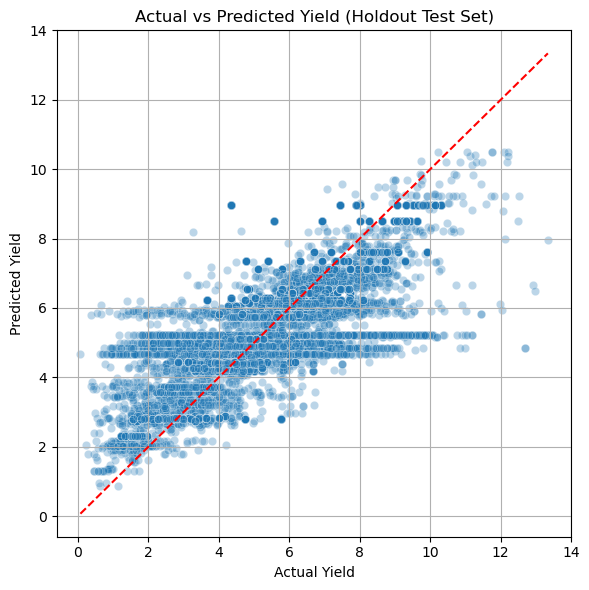

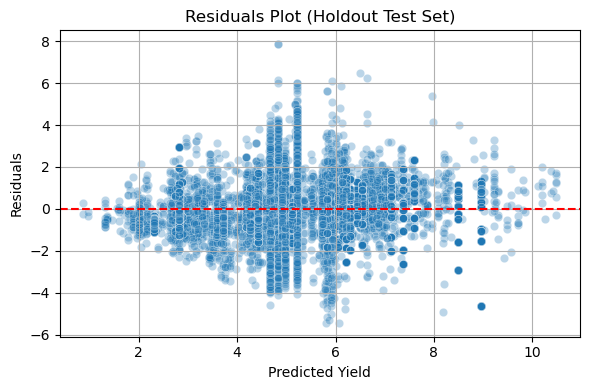

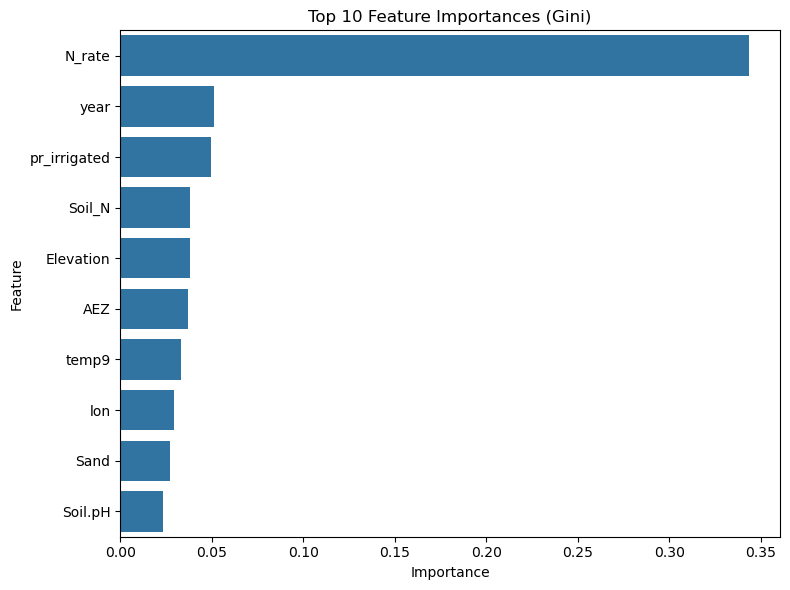

100%|===================| 13885/13886 [06:04<00:00]        /tmp/ipykernel_202056/3387603753.py:78: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


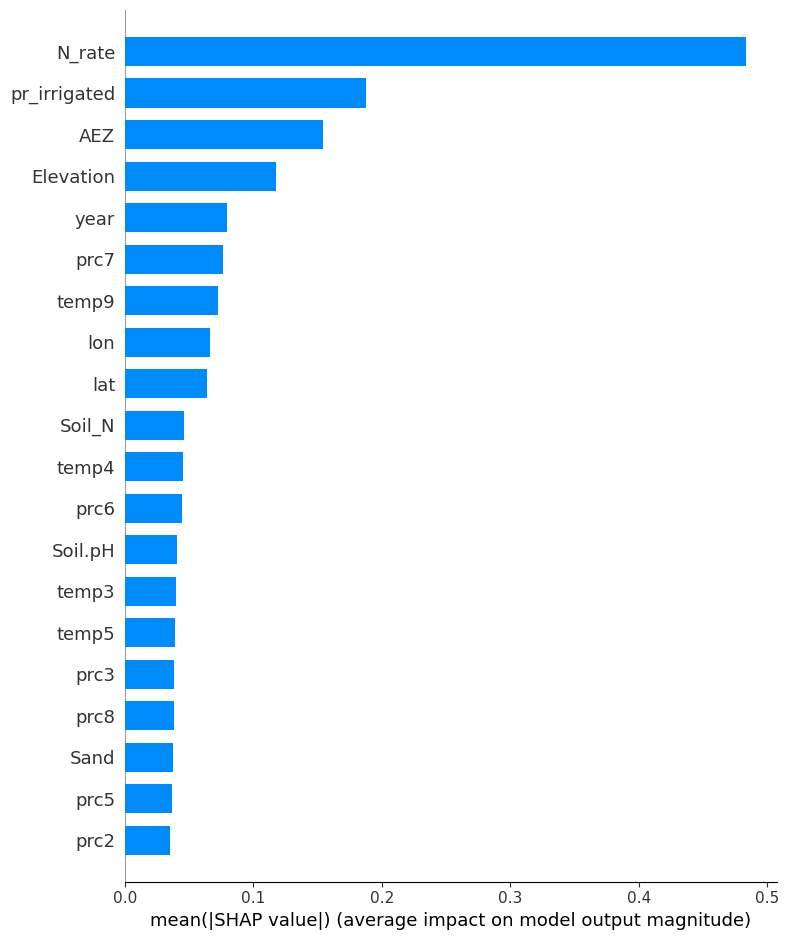

/tmp/ipykernel_202056/3387603753.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


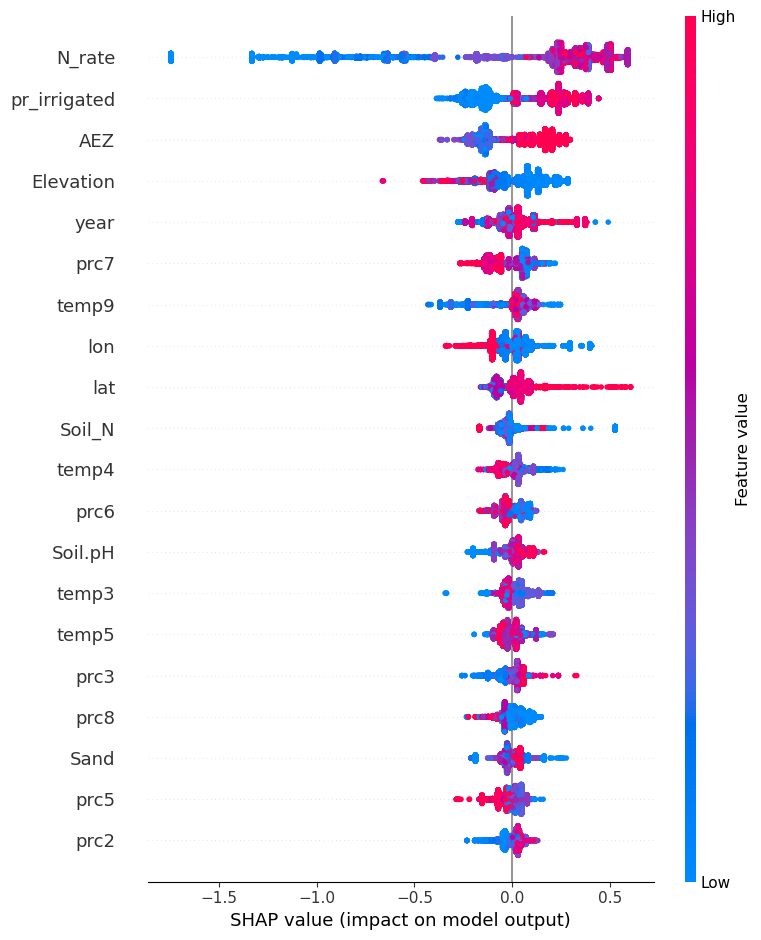

In [22]:
from sklearn.ensemble import RandomForestRegressor
import time
import shap

# Use best parameters from random search
best_params = search.best_params_

# Build final RF model
best_model = RandomForestRegressor(
    **best_params,
    n_jobs=-1,
    random_state=0
)

# Train on full training+validation set
start_time = time.time()
best_model.fit(X_trainval, y_trainval)
print(f"Final model trained in {(time.time() - start_time)/60:.2f} minutes.")

# Predict on holdout test set
y_pred = best_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Holdout Test Set Evaluation Metrics:")
print(f"  MAE : {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²  : {r2:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield (Holdout Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals Plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Holdout Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance (RF native)
importances = best_model.feature_importances_
feature_names = X_trainval.columns if hasattr(X_trainval, 'columns') else [f"f{i}" for i in range(X_trainval.shape[1])]
import pandas as pd

feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot Top 10 Importances
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importances (Gini)")
plt.tight_layout()
plt.show()

# SHAP Explanation (compatible with tree-based models like RF)
explainer = shap.Explainer(best_model, X_trainval)
shap_values = explainer(X_test)

# SHAP Summary: Bar Plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# SHAP Summary: Beeswarm Plot
shap.summary_plot(shap_values, X_test)